## **PART A -- Baseline Foundations on NLP**

## **TASK 1: Data Loading AND Preparation**

* **Dataset**
* **Split**
* **Structure**

Provided with 3 seperate text files: `train.txt`, `val.txt` and `test.txt`

All datasets contain 6 distinct emotions (Anger, Fear, Love, Joy, Sadness or Suprise). 

In [1]:
print('='*50)
print("Part A - Task 1: Data Loading & Preparation")
print('='*50)
print()

#Import Libraries

#----Core Libraries----
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt

#----NLTK Libraries----
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

#----Sckit-Learn: Feature Extraction Text----
from sklearn.feature_extraction.text import TfidfVectorizer

#----Tensorflow Libraries----
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

#----Scikit-Learn: Metrics----
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

#Set nltk language to 'english'
nltk_stopwords = stopwords.words('english')

print('Libraries imported!')

Part A - Task 1: Data Loading & Preparation

Libraries imported!


In [2]:
#Set the directories as variable for efficiency
TRAIN_FILE = './data/train.txt'
VALID_FILE = './data/val.txt'
TEST_FILE = './data/test.txt'

print("File Directories as variables set!")

File Directories as variables set!


In [3]:
#Load the 3 data files of Train, Valid and Test.txt
df01 = pd.read_table(TRAIN_FILE, sep=';', header=None, names=['text', 'labels'])
print("train.txt")
display(df01.head())

df02 = pd.read_table(VALID_FILE, sep=';', header=None, names=['text', 'labels'])
print("val.txt")
display(df02.head())

df03 = pd.read_table(TEST_FILE, sep=';', header=None, names=['text', 'labels'])
print("test.txt")
display(df03.head())

print("Loading & Preparation executed!")

train.txt


,text,labels
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


val.txt


,text,labels
0,im feeling quite sad and sorry for myself but ...,sadness
1,i feel like i am still looking at a blank canv...,sadness
2,i feel like a faithful servant,love
3,i am just feeling cranky and blue,anger
4,i can have for a treat or if i am feeling festive,joy


test.txt


,text,labels
0,im feeling rather rotten so im not very ambiti...,sadness
1,im updating my blog because i feel shitty,sadness
2,i never make her separate from me because i do...,sadness
3,i left with my bouquet of red and yellow tulip...,joy
4,i was feeling a little vain when i did this one,sadness


Loading & Preparation executed!


## **TASK 2: Text Preprocessing & Vectorization**

* **Cleaning & Preprocessing**
* **Vectorization**


In [4]:
def clean(input_text):
    output_text = str(input_text).translate(str.maketrans('', '', string.punctuation))
    output_text = output_text.lower()
    output_text = re.sub(r'\d+', '', output_text)
    return output_text

def lemm_text(input_text):
    lemmatizer = WordNetLemmatizer()
    words = word_tokenize(input_text)
    words = [word for word in words if word.lower() not in nltk_stopwords]
    lemmatize_words = [lemmatizer.lemmatize(word) for word in words]
    lemm_output = ' '.join(lemmatize_words)
    return lemm_output

def process_with_lemm(input_text):
    output_text = clean(input_text)
    final_text = lemm_text(output_text)
    return final_text

In [5]:
print('='*50)
print("Part A - TASK 2: Text Preprocessing & Vectorization")
print('='*50)
print()

df01_clean = df01.copy()
df01_clean['clean_text'] = df01_clean['text'].apply(process_with_lemm)

df02_clean = df02.copy()
df02_clean['clean_text'] = df02_clean['text'].apply(process_with_lemm)

df03_clean = df03.copy()
df03_clean['clean_text'] = df03_clean['text'].apply(process_with_lemm)


print("train.txt (Cleaned Version)")
display(df01_clean[['clean_text', 'labels']].head())
print()
print("Cleaning Done!")

Part A - TASK 2: Text Preprocessing & Vectorization

train.txt (Cleaned Version)


,clean_text,labels
0,didnt feel humiliated,sadness
1,go feeling hopeless damned hopeful around some...,sadness
2,im grabbing minute post feel greedy wrong,anger
3,ever feeling nostalgic fireplace know still pr...,love
4,feeling grouchy,anger



Cleaning Done!


In [6]:
print('='*50)
print("Part A - Task 2: Vectorization")
print('='*50)
print()
tfidf_vectorizer = TfidfVectorizer(max_features=5000)

X_train = tfidf_vectorizer.fit_transform(df01_clean['clean_text'])
X_val = tfidf_vectorizer.transform(df02_clean['clean_text'])
X_test = tfidf_vectorizer.transform(df03_clean['clean_text'])

y_train = pd.get_dummies(df01_clean['labels'])
y_val = pd.get_dummies(df02_clean['labels'])
y_test = pd.get_dummies(df03_clean['labels'])

print("Vectorization completed!")

Part A - Task 2: Vectorization

Vectorization completed!


In [7]:
X_train

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 134310 stored elements and shape (16000, 5000)>

In [8]:
y_train.head()

,anger,fear,joy,love,sadness,surprise
0,False,False,False,False,True,False
1,False,False,False,False,True,False
2,True,False,False,False,False,False
3,False,False,False,True,False,False
4,True,False,False,False,False,False


## **TASK 3: Baseline Neural Network**

* **Architecture**
* **Training**

In [9]:
model = Sequential()

model.add(Dense(64, input_dim=X_train.shape[1], activation='relu'))

model.add(Dense(y_train.shape[1], activation='softmax'))

c:\Users\Zach Ng\miniconda3\envs\NLPE\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [11]:
num_epochs = 5
history = model.fit(X_train, y_train, epochs=num_epochs, validation_data=(X_val, y_val))

Epoch 1/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6012 - loss: 1.2003 - val_accuracy: 0.8365 - val_loss: 0.6515
Epoch 2/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9072 - loss: 0.3806 - val_accuracy: 0.8875 - val_loss: 0.3548
Epoch 3/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9538 - loss: 0.1856 - val_accuracy: 0.8865 - val_loss: 0.3153
Epoch 4/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9699 - loss: 0.1207 - val_accuracy: 0.8865 - val_loss: 0.3188
Epoch 5/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9796 - loss: 0.0872 - val_accuracy: 0.8860 - val_loss: 0.3267


## **TASK 4: Evaluation & Metrics**

* **Curves**
* **Testing**
* **Visualization**

In [12]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Accuracy: {accuracy}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8725 - loss: 0.3294
Accuracy: 0.8725000023841858


In [13]:
print(y_test.shape)

print(y_test[0:5])

(2000, 6)
   anger   fear    joy   love  sadness  surprise
0  False  False  False  False     True     False
1  False  False  False  False     True     False
2  False  False  False  False     True     False
3  False  False   True  False    False     False
4  False  False  False  False     True     False


In [14]:
preds = model.predict(X_test)

print(preds.shape)
print()
print(preds[0:5])

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
(2000, 6)

[[4.7284181e-04 7.4621472e-05 9.3524126e-05 6.1206825e-05 9.9922407e-01
  7.3755480e-05]
 [1.9665615e-04 8.9455752e-06 3.0148507e-05 2.2535128e-06 9.9975687e-01
  5.1690390e-06]
 [1.2365006e-03 2.8813481e-03 2.5086399e-02 7.8076037e-04 9.6975076e-01
  2.6420000e-04]
 [3.7605520e-03 2.7873532e-03 9.9058694e-01 3.7866124e-04 2.0833011e-03
  4.0319597e-04]
 [1.7770522e-05 5.8155110e-05 6.1649327e-05 3.9844872e-06 9.9983954e-01
  1.8897674e-05]]


In [15]:
preds_cm = [np.argmax(each) for each in preds]
print(preds_cm[0:5])
print()
y_preds_cm = [np.argmax(each) for each in y_test.values]
print(y_preds_cm)

[np.int64(4), np.int64(4), np.int64(4), np.int64(2), np.int64(4)]

[np.int64(4), np.int64(4), np.int64(4), np.int64(2), np.int64(4), np.int64(1), np.int64(0), np.int64(2), np.int64(2), np.int64(0), np.int64(1), np.int64(4), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(2), np.int64(4), np.int64(0), np.int64(2), np.int64(4), np.int64(2), np.int64(2), np.int64(4), np.int64(4), np.int64(1), np.int64(0), np.int64(4), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(4), np.int64(0), np.int64(4), np.int64(2), np.int64(2), np.int64(4), np.int64(2), np.int64(2), np.int64(0), np.int64(4), np.int64(2), np.int64(4), np.int64(2), np.int64(0), np.int64(2), np.int64(2), np.int64(1), np.int64(1), np.int64(4), np.int64(1), np.int64(2), np.int64(4), np.int64(2), np.int64(4), np.int64(4), np.int64(2), np.int64(4), np.int64(0), np.int64(4), np.int64(4), np.int64(2), np.int64(2), np.int64(4), np.int64(5), np.int64(4), np.int64(0), np.int64(1), np.int64(5), np.int64(2), np.int64(

In [16]:
emotion_labels = sorted(df01_clean['labels'].unique())
print("Labels:", emotion_labels)

Labels: ['anger', 'fear', 'joy', 'love', 'sadness', 'surprise']


In [17]:
cm = confusion_matrix(y_preds_cm, preds_cm)
cm

array([[238,   7,  11,   0,  19,   0],
       [ 12, 181,   8,   1,  15,   7],
       [  3,   5, 642,  32,   8,   5],
       [  3,   1,  35, 115,   5,   0],
       [ 20,   7,  24,   1, 529,   0],
       [  3,  11,   9,   0,   3,  40]])

In [18]:
df_cm = pd.DataFrame(cm, index=emotion_labels, columns=emotion_labels)
print(df_cm)

          anger  fear  joy  love  sadness  surprise
anger       238     7   11     0       19         0
fear         12   181    8     1       15         7
joy           3     5  642    32        8         5
love          3     1   35   115        5         0
sadness      20     7   24     1      529         0
surprise      3    11    9     0        3        40


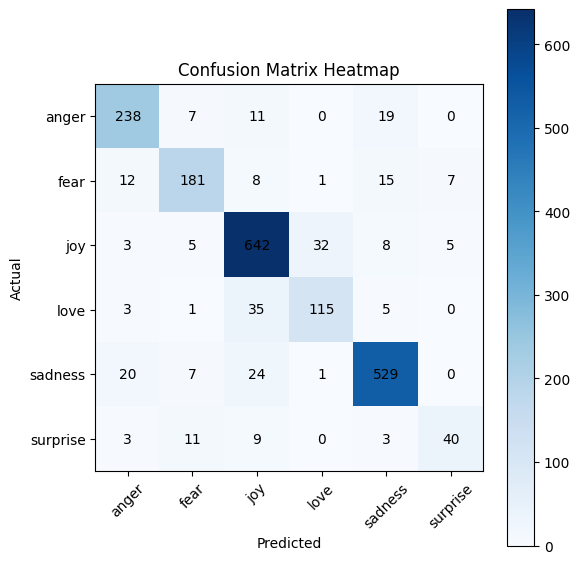

In [19]:
#Plot Heatmap
plt.figure(figsize=(6, 6))
plt.imshow(cm, cmap='Blues')
plt.colorbar()
plt.xticks(range(6), emotion_labels, rotation=45)
plt.yticks(range(6), emotion_labels)

for i in range(6):
    for j in range(6):
        plt.text(j, i, cm[i,j], ha='center', va='center')

plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [20]:
print(classification_report(y_preds_cm, preds_cm, target_names=emotion_labels))

print('='*50)
print("Evaluation & Metrics Complete")
print('='*50)

              precision    recall  f1-score   support

       anger       0.85      0.87      0.86       275
        fear       0.85      0.81      0.83       224
         joy       0.88      0.92      0.90       695
        love       0.77      0.72      0.75       159
     sadness       0.91      0.91      0.91       581
    surprise       0.77      0.61      0.68        66

    accuracy                           0.87      2000
   macro avg       0.84      0.81      0.82      2000
weighted avg       0.87      0.87      0.87      2000

Evaluation & Metrics Complete


Loss and Accuracy Curves (Baseline)


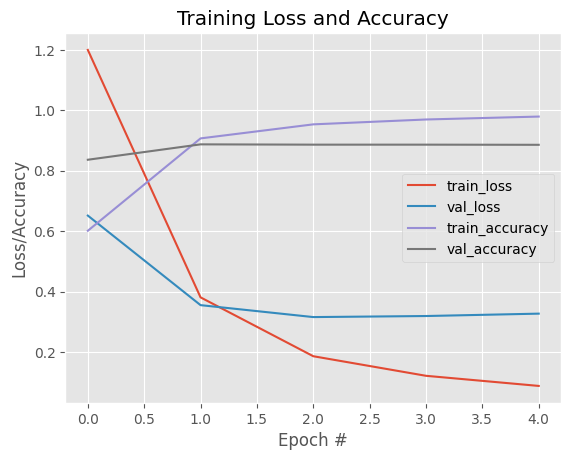

In [21]:
print('='*50)
print("Loss and Accuracy Curves (Baseline)")
print('='*50)

def plot_graphs(H, metric):
    plt.style.use('ggplot')
    plt.figure()
    plt.plot(np.arange(0, num_epochs), H.history['loss'], label="train_loss")
    plt.plot(np.arange(0, num_epochs), H.history['val_loss'], label="val_loss")
    plt.plot(np.arange(0, num_epochs), H.history['accuracy'], label="train_accuracy")
    plt.plot(np.arange(0, num_epochs), H.history['val_accuracy'], label="val_accuracy")
    plt.title('Training Loss and Accuracy')
    plt.xlabel('Epoch #')
    plt.ylabel('Loss/Accuracy')
    plt.legend()
    plt.show()
plot_graphs(history, 'accuracy')

## **TASK 5: Testing on Unseen Data**

* **Live Prediction**

In [22]:
def encode_sentence(input_text):
    cleaned_text = process_with_lemm(input_text)
    encoded_text = tfidf_vectorizer.transform([cleaned_text])
    encoded_text = encoded_text.toarray()
    return encoded_text

def prediction(encoded_text):
    emotion_labels = sorted(df01_clean['labels'].unique())
    predictions = model.predict(encoded_text)
    predicted_class = np.argmax(predictions)
    print("The predicted probability is:", predictions)
    print("The predicted class is:", predicted_class)
    print("The predicted emotion is:", emotion_labels[predicted_class])

In [23]:
print('='*50)
print("PART A - Task 5: Testing on Unseen Data")
print('='*50)

new_text = "I am so incredibly angry right now!"
encoded = encode_sentence(new_text)
prediction(encoded)

print('='*50)
print("Testing on Unseen Sentences Complete!")
print('='*50)

PART A - Task 5: Testing on Unseen Data
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
The predicted probability is: [[0.8700332  0.01318973 0.00990685 0.00109058 0.09671124 0.00906838]]
The predicted class is: 0
The predicted emotion is: anger
Testing on Unseen Sentences Complete!
